Part 1: Fetch tweets under #memecoin and #socialfi accounts

In [118]:
import nest_asyncio
nest_asyncio.apply()

In [216]:
import asyncio
from twikit import Client 

# Import the twitter account 
USERNAME = 'USERNAME'  # your_twitter_account
EMAIL = 'EMAIL'
PASSWORD = 'PASSWORD'

# Initialize client
client = Client('en-US')

async def main():
    await client.login(
        auth_info_1=USERNAME,
        auth_info_2=EMAIL,
        password=PASSWORD,
        cookies_file='cookies.json'
    )

asyncio.run(main())

In [214]:
#To check the format of user.created_at_datetime，so I can filter the qualified user account
result = await client.search_user('elonmusk')

for user in result:
    print(user.created_at_datetime)

2024-08-20 08:58:38+00:00


In [5]:
#Filter qualified twitter accounts of #memecoin
import pandas as pd

cutoff_date = '2023-02-01' 
filtered_user_names = set()

users = await client.search_user('#memecoin', 20, None) #let's filter #memecoin accounts first
user_data = []

while len(filtered_user_names) < 100 and users:
    for user in users:
        if (user.description and
            ('#memecoin' in user.description.lower() or '$' in user.description.lower()) and
            user.created_at[:10] > cutoff_date): # Filter accounts created in last two years

            filtered_user_names.add(user.screen_name) # Fetch accounts information
            user_data.append({
                'account':user.screen_name, # Screen name is the unique name of an account
                'followers':user.followers_count, 
                'created_date':user.created_at,
                'bio':user.description,    # Bio information
                'tweets':user.statuses_count # The number of tweets
            })
        
        if len(filtered_user_names) >= 100:  # Collect 100 accounts
            break
        
    if len(filtered_user_names) < 100:
        await asyncio.sleep(20)
        users = await users.next()

df = pd.DataFrame(user_data)

print(f"Total number of twitter accounts {len(df)} ")
df.to_csv('memecoin_account.csv',index=False)  # Save the data to a CSV file
        

Total number of twitter accounts 100 


In [18]:
#Sort value on memecoin accounts according to followers and tweets number
df = pd.read_csv('memecoin_account.csv')
df = df[['account','followers','tweets','created_date','bio']] # Read the table structure
df_sorted = df.sort_values(['followers'], ascending=[False])   # Sort data according to its follower size

df_sorted.to_csv('memecoin_account_sorted.csv', index=False)  # Save the sorted result to a new file.
df_sorted = df_sorted.reset_index(drop=True)

print(df_sorted.head(10))  # Print the first 10 rows for manual check

          account  followers  tweets                    created_date  \
0        memecoin    1978010       4  Tue Apr 26 10:21:39 +0000 2022   
1     TeaMemeCoin     493211     385  Sat Jun 22 19:15:00 +0000 2024   
2        ctancoin     345888   15378  Wed Apr 07 03:17:18 +0000 2010   
3     NBAMemeCoin     254146    6238  Fri Mar 20 05:50:19 +0000 2009   
4   ElonMusk_Pump     226123    1718  Fri Jul 29 16:02:06 +0000 2022   
5    ParkMemeCoin     212925      24  Wed Jan 24 03:16:55 +0000 2024   
6    ConceitedNYC     195460   79793  Sat May 02 10:34:36 +0000 2009   
7  CryptoDefiGems     184447    8111  Sun Jun 27 08:19:46 +0000 2021   
8   hard_protocol     171895     211  Thu Sep 10 23:08:41 +0000 2020   
9   WaterMemeCoin     149160     404  Sun Jun 16 17:11:55 +0000 2024   

                                                 bio  
0                                The ticker is $MEME  
1  cu-$TEA memecoin on #Solana 🍃💸 3M in Telegram ...  
2  Chiitan☆Coin is @chiitan7407 Official M

In [22]:
#Fetch tweets of qualified memecoin accounts
#Aim at fetching 1,600 tweets under #memecoin accounts
df_accounts = pd.read_csv('memecoin_account.csv')

df_filtered = df_accounts.query('tweets > 40') # I fetch the tweets of accounts who at least have 40 tweets, to ensure they got enough for fetching in the next procedure.

df_top80 = df_filtered.sort_values('followers',ascending=False).head(80) # Select top 80 accounts

tweets_data = []

for index,account in df_top80.iterrows():
    print(f"collecting tweets of {account['account'],index+1}/80")  # I can track the process with the print
    user = await client.get_user_by_screen_name(account['account']) # Fetch tweets based on the uniqe account name
    if user:
        all_tweets = []
        tweets = await client.get_user_tweets(user.id,'Tweets',20,None) # We only get 20 tweets for each account

        while tweets:                
            all_tweets.extend([{  # All information will be saved to the list all_tweets
                'account':account['account'],    # Twitter uniqe account name
                'text':tweet.text,               # Tweets
                'hashtags':','.join(tweet.hashtags) if tweet.hashtags else '',  # I also save the hashtag in case I need it
                'created_at':tweet.created_at   # The creation time in case I need it
            } for tweet in tweets])

            if len(all_tweets)>=20:             # I stop if there have been 20 tweets
                break

            tweets = await tweets.next()       # If there's less than 20, we request another time for the next page

        tweets_data.extend(all_tweets[:20])    # We only fetch the first 20 tweets if there's more than 20
        print(f"✓ Added {len(all_tweets[:20])} tweets")
        print(f"Current total tweets: {len(tweets_data)}")     # So I can see the total number of tweets during the fetching process

    await asyncio.sleep(60)                   # We set a rest time of 60 seconds.

df_tweets = pd.DataFrame(tweets_data)         
df_tweets.to_csv('memecoin_tweets.csv',index=False)  # The data will be saved to a new CSV file

print(df_tweets.head(10))                    # Print the first 10 rows for manual check

collecting tweets of ('TeaMemeCoin', 3)/80
✓ Added 20 tweets
Current total tweets: 20
collecting tweets of ('ctancoin', 68)/80
✓ Added 20 tweets
Current total tweets: 40
collecting tweets of ('NBAMemeCoin', 77)/80
✓ Added 0 tweets
Current total tweets: 40
collecting tweets of ('ElonMusk_Pump', 34)/80
✓ Added 20 tweets
Current total tweets: 60
collecting tweets of ('ConceitedNYC', 52)/80
✓ Added 20 tweets
Current total tweets: 80
collecting tweets of ('CryptoDefiGems', 83)/80
✓ Added 20 tweets
Current total tweets: 100
collecting tweets of ('hard_protocol', 97)/80
✓ Added 20 tweets
Current total tweets: 120
collecting tweets of ('WaterMemeCoin', 6)/80
✓ Added 20 tweets
Current total tweets: 140
collecting tweets of ('catecoin', 73)/80
✓ Added 20 tweets
Current total tweets: 160
collecting tweets of ('PumpBigPump', 64)/80
✓ Added 20 tweets
Current total tweets: 180
collecting tweets of ('TurboToadToken', 62)/80
✓ Added 20 tweets
Current total tweets: 200
collecting tweets of ('MemeCoinOw

In [24]:
#Filter qualified twitter accounts of #socialfi
cutoff_date = '2023-02-01'
filtered_user_names = set()

users = await client.search_user('#socialfi', 20, None) #let's filter #socialfi accounts then
user_data = []

while len(filtered_user_names) < 100 and users:
    for user in users:
        if (user.description and
            ('#socialfi' in user.description.lower() or '$' in user.description.lower()) and
            user.created_at[:10] > cutoff_date):

            filtered_user_names.add(user.screen_name)
            user_data.append({
                'account':user.screen_name,
                'followers':user.followers_count,
                'created_date':user.created_at,
                'bio':user.description,
                'tweets':user.statuses_count
            })
        
        if len(filtered_user_names) >= 100:
            break
        
    if len(filtered_user_names) < 100:
        await asyncio.sleep(20)
        users = await users.next()

df = pd.DataFrame(user_data)

print(f"Total number of twitter accounts {len(df)} ")
df.to_csv('socialfi_account.csv',index=False)

Total number of twitter accounts 100 


In [26]:
#Sort value on socialfi accounts according to followers and tweets number
df = pd.read_csv('socialfi_account.csv')
df = df[['account','followers','tweets','created_date','bio']]
df_sorted = df.sort_values(['followers', 'tweets'], ascending=[False, False])
df_sorted = df_sorted.reset_index(drop=True)

df_sorted.to_csv('socialfi_account_sorted.csv', index=False)

print(df_sorted.head(10))

         account  followers  tweets                    created_date  \
0       metyacom     788839     962  Tue Nov 30 10:46:10 +0000 2021   
1      Friend3AI     293940    1732  Mon Apr 03 04:29:56 +0000 2023   
2   PiNetwork_35     256250    2175  Thu Mar 24 10:52:13 +0000 2022   
3  PulseSocialFi     207802     983  Thu May 30 04:56:13 +0000 2024   
4    _s_l_a_t_e_     201094    3390  Wed Dec 25 09:56:29 +0000 2013   
5       METYA_HK     200177   17891  Tue Mar 19 16:52:23 +0000 2013   
6      SoMon_OwO     171266     584  Fri Mar 15 04:31:05 +0000 2024   
7       GameCelt     123254     996  Thu Jan 18 04:59:25 +0000 2018   
8   dyorexchange     103282    3054  Mon Apr 04 09:28:59 +0000 2022   
9       Metya_JP      96477     358  Wed Jun 05 22:17:50 +0000 2024   

                                                 bio  
0  Metya is AI-driven web3 dating platform. Over ...  
1  Launch your AI agents with one click to make f...  
2  Pi Network is first degital mobile mining app.... 

In [54]:
#Fetch tweets of qualified socialfi accounts
#Aim at fetching 1,600 tweets under #socialfi accounts
#Print the top 80 accounts and manually delete the non-english accounts
df_accounts = pd.read_csv('socialfi_account.csv')
df_filtered = df_accounts.query('tweets > 40')
df_top80 = df_filtered.sort_values('followers',ascending=False).head(80)

df_en = df_sorted[
    (~df_sorted['account'].str.lower().str.contains('metya') |   # I found there're several accounts of non-Engligh language derived from metya, so I only retain metyacom and leave out other one
     (df_sorted['account'].str.lower() == 'metyacom')) &
    (df_sorted['account'].str.lower() != 'pulse__socialfi')      # Puse_socialfi is a Janpanese language account
]

df_top100 = df_en.head(100)
df_top100.to_csv('socialfi_top80_filtered.csv', index=False)

print(df_top80)

          account  followers  tweets                    created_date  \
0        metyacom     788839     962  Tue Nov 30 10:46:10 +0000 2021   
1       Friend3AI     293940    1732  Mon Apr 03 04:29:56 +0000 2023   
2    PiNetwork_35     256250    2175  Thu Mar 24 10:52:13 +0000 2022   
3   PulseSocialFi     207802     983  Thu May 30 04:56:13 +0000 2024   
4     _s_l_a_t_e_     201094    3390  Wed Dec 25 09:56:29 +0000 2013   
..            ...        ...     ...                             ...   
94    linkd_world        135      27  Wed Nov 01 08:02:27 +0000 2023   
95   XRPTalk_real         91      15  Sat Oct 19 17:01:22 +0000 2024   
96   SocialFI2025         49     328  Thu Jan 21 12:07:07 +0000 2021   
97   SocialFi_sol         24     650  Wed Oct 30 21:34:11 +0000 2024   
99    SafSocialFi          6      34  Sat May 28 20:36:22 +0000 2022   

                                                  bio  
0   Metya is AI-driven web3 dating platform. Over ...  
1   Launch your AI agen

In [62]:
#Fetch tweets from qualified #socialfi accounts
#But I'm afraid of hitting the web-scraping limit very soon, so I decided to fetch 400 by 400.
df_top80 = pd.read_csv('socialfi_top80_filtered.csv')
tweets_data = []

for index, account in df_top80.iterrows():
    
    if len(tweets_data)>= 400:
        print(f"Finish fetching 400 tweets")
        break

    print(f"collecting tweets of {account['account']}, {index+1}/100")
    user = await client.get_user_by_screen_name(account['account'])
    
    if user:
        all_tweets = []
        tweets = await client.get_user_tweets(user.id, 'Tweets', 20, None)
        
        while tweets:
            all_tweets.extend([{
                'account': account['account'],
                'text': tweet.text,
                'hashtags': ','.join(tweet.hashtags) if tweet.hashtags else '',
                'created_at': tweet.created_at
                } for tweet in tweets])

            if len(all_tweets) >= 20:
                break

            tweets = await tweets.next()
            if not tweets:
                break

        tweets_data.extend(all_tweets)
        print(f"✓ {len(all_tweets)} tweets have been added")
        print(f"Current numbers of tweet in tweets_data is: {len(tweets_data)}")

    await asyncio.sleep(60)

df_tweets = pd.DataFrame(tweets_data)
df_tweets.to_csv('socialfi_tweets.csv', index=False)

print(df_tweets.head(10))
print(len(df_tweets))

collecting tweets of metyacom, 1/100
✓ 34 tweets have been added
Current numbers of tweet in tweets_data is: 34
collecting tweets of Friend3AI, 2/100
✓ 35 tweets have been added
Current numbers of tweet in tweets_data is: 69
collecting tweets of PiNetwork_35, 3/100
✓ 40 tweets have been added
Current numbers of tweet in tweets_data is: 109
collecting tweets of PulseSocialFi, 4/100
✓ 39 tweets have been added
Current numbers of tweet in tweets_data is: 148
collecting tweets of _s_l_a_t_e_, 5/100
✓ 38 tweets have been added
Current numbers of tweet in tweets_data is: 186
collecting tweets of SoMon_OwO, 6/100
✓ 32 tweets have been added
Current numbers of tweet in tweets_data is: 218
collecting tweets of GameCelt, 7/100
✓ 31 tweets have been added
Current numbers of tweet in tweets_data is: 249
collecting tweets of dyorexchange, 8/100
✓ 34 tweets have been added
Current numbers of tweet in tweets_data is: 283
collecting tweets of influpia, 9/100
✓ 35 tweets have been added
Current numbers

In [76]:
# When trying to fetch another 400 tweets, I found another problem.
# This time I'm only allowed to fetch 260.

df_top80 = pd.read_csv('socialfi_top80_filtered.csv')
df_remaining = df_top80.iloc[12:]
tweets_data = []

for index, account in df_remaining.iterrows():
    
    if len(tweets_data)>= 250:
        print(f"Finish fetching 400 tweets")
        break

    print(f"collecting tweets of {account['account']}, {index+1}/100")
    user = await client.get_user_by_screen_name(account['account'])
    
    if user:
        all_tweets = []
        tweets = await client.get_user_tweets(user.id, 'Tweets', 20, None)
        
        while tweets:
            all_tweets.extend([{
                'account': account['account'],
                'text': tweet.text,
                'hashtags': ','.join(tweet.hashtags) if tweet.hashtags else '',
                'created_at': tweet.created_at
                } for tweet in tweets])

            if len(all_tweets) > 20:
                break

            tweets = await tweets.next()
            if not tweets:
                break

        tweets_data.extend(all_tweets)
        print(f"✓ {len(all_tweets)} tweets have been added")
        print(f"Current numbers of tweet in tweets_data is: {len(tweets_data)}")

    await asyncio.sleep(60)

df_tweets = pd.DataFrame(tweets_data)
df_tweets.to_csv('socialfi_tweets_1.csv', index=False)

df_existing = pd.read_csv('socialfi_tweets.csv')
df_new = pd.read_csv('socialfi_tweets_1.csv')

df_combined = pd.concat([df_existing, df_new], ignore_index=True)

df_combined.to_csv('socialfi_tweets.csv', index=False)

print(df_combined.head(10))
print(len(df_tweets))

collecting tweets of facedaoio, 13/100
✓ 38 tweets have been added
Current numbers of tweet in tweets_data is: 38
collecting tweets of Envo_Official, 14/100
✓ 39 tweets have been added
Current numbers of tweet in tweets_data is: 77
collecting tweets of GenZee_live, 15/100
✓ 3 tweets have been added
Current numbers of tweet in tweets_data is: 80
collecting tweets of xninja_tech, 16/100
✓ 38 tweets have been added
Current numbers of tweet in tweets_data is: 118
collecting tweets of NewCoinListings, 17/100
✓ 37 tweets have been added
Current numbers of tweet in tweets_data is: 155
collecting tweets of floyxcom, 18/100
✓ 39 tweets have been added
Current numbers of tweet in tweets_data is: 194
collecting tweets of gemsgg_official, 19/100
✓ 40 tweets have been added
Current numbers of tweet in tweets_data is: 234
collecting tweets of trendhub_one, 20/100
✓ 34 tweets have been added
Current numbers of tweet in tweets_data is: 268
Finish fetching 400 tweets
    account                        

In [234]:
# Another problem: 
# Some twitter accounts have been suspended for unkown reasons, so I need to add another filter to leave out those suspended.

df_top80 = pd.read_csv('socialfi_top80_filtered.csv')
df_remaining = df_top80.iloc[21:]
tweets_data = []

for index, account in df_remaining.iterrows():
    
    if len(tweets_data)>= 400:
        print(f"Finish fetching 400 tweets")
        break

    print(f"collecting tweets of {account['account']}, {index+1}/80")
    user = await client.get_user_by_screen_name(account['account'])
    
    if user:
        all_tweets = []
        tweets = await client.get_user_tweets(user.id,'Tweets',20,None)
        
        while tweets:
            all_tweets.extend([{
                'account': account['account'],
                'text': tweet.text,
                'hashtags': ','.join(tweet.hashtags) if tweet.hashtags else '',
                'created_at': tweet.created_at
                } for tweet in tweets])

            if len(all_tweets) >= 20:
                break

            tweets = await tweets.next()
            if not tweets:
                break

        tweets_data.extend(all_tweets[:20])
        print(f"✓ {len(all_tweets[:20])} tweets have been added")
        print(f"Current numbers of tweet in tweets_data is: {len(tweets_data)}")

    await asyncio.sleep(60)

df_tweets = pd.DataFrame(tweets_data)
df_tweets.to_csv('socialfi_tweets_3.csv', index=False)

df_existing = pd.read_csv('socialfi_tweets.csv')
df_new = pd.read_csv('socialfi_tweets_3.csv')

df_combined = pd.concat([df_existing, df_new], ignore_index=True)

df_combined.to_csv('socialfi_tweets.csv', index=False)

print(df_combined.head(10))
print(len(df_tweets))

collecting tweets of pluschain41213, 22/80
✓ 20 tweets have been added
Current numbers of tweet in tweets_data is: 20
collecting tweets of aZen_Dao, 23/80
✓ 20 tweets have been added
Current numbers of tweet in tweets_data is: 40
collecting tweets of torum_official, 24/80
✓ 20 tweets have been added
Current numbers of tweet in tweets_data is: 60
collecting tweets of farmroll_io, 25/80
✓ 20 tweets have been added
Current numbers of tweet in tweets_data is: 80
collecting tweets of MoonFitOfficial, 26/80
✓ 20 tweets have been added
Current numbers of tweet in tweets_data is: 100
collecting tweets of btcw_tech, 27/80
✓ 0 tweets have been added
Current numbers of tweet in tweets_data is: 100
collecting tweets of rogerg8001, 28/80
✓ 20 tweets have been added
Current numbers of tweet in tweets_data is: 120
collecting tweets of PixieApp, 29/80
✓ 20 tweets have been added
Current numbers of tweet in tweets_data is: 140
collecting tweets of SaTT_Token, 30/80
✓ 20 tweets have been added
Current n

In [236]:
# Let's try to fetch the following twitter accounts this time and try to add another 600-700 tweets

df_top80 = pd.read_csv('socialfi_top80_filtered.csv')
df_remaining = df_top80.iloc[44:]
tweets_data = []

for index, account in df_remaining.iterrows():
    
    if len(tweets_data)>= 700:
        print(f"Finish fetching 700 tweets")
        break

    print(f"collecting tweets of {account['account']}, {index+1}/80")
    user = await client.get_user_by_screen_name(account['account'])
    
    if user:
        all_tweets = []
        tweets = await client.get_user_tweets(user.id,'Tweets',20,None)
        
        while tweets:
            all_tweets.extend([{
                'account': account['account'],
                'text': tweet.text,
                'hashtags': ','.join(tweet.hashtags) if tweet.hashtags else '',
                'created_at': tweet.created_at
                } for tweet in tweets])

            if len(all_tweets) >= 20:
                break

            tweets = await tweets.next()
            if not tweets:
                break

        tweets_data.extend(all_tweets[:20])
        print(f"✓ {len(all_tweets[:20])} tweets have been added")
        print(f"Current numbers of tweet in tweets_data is: {len(tweets_data)}")

    await asyncio.sleep(60)

df_tweets = pd.DataFrame(tweets_data)
df_tweets.to_csv('socialfi_tweets_4.csv', index=False)

df_existing = pd.read_csv('socialfi_tweets.csv')
df_new = pd.read_csv('socialfi_tweets_4.csv')

df_combined = pd.concat([df_existing, df_new], ignore_index=True)

df_combined.to_csv('socialfi_tweets.csv', index=False)

print(df_combined.head(10))
print(len(df_tweets))

collecting tweets of openchaty, 45/80
✓ 20 tweets have been added
Current numbers of tweet in tweets_data is: 20
collecting tweets of MonsterLord2024, 46/80
✓ 20 tweets have been added
Current numbers of tweet in tweets_data is: 40
collecting tweets of xtask_xyz, 47/80
✓ 20 tweets have been added
Current numbers of tweet in tweets_data is: 60
collecting tweets of erc_quest, 48/80
✓ 20 tweets have been added
Current numbers of tweet in tweets_data is: 80
collecting tweets of futtrillionaire, 49/80
✓ 20 tweets have been added
Current numbers of tweet in tweets_data is: 100
collecting tweets of xQuest_tech, 50/80
✓ 20 tweets have been added
Current numbers of tweet in tweets_data is: 120
collecting tweets of HooCrypto, 51/80
✓ 20 tweets have been added
Current numbers of tweet in tweets_data is: 140
collecting tweets of gemgemcrypto, 52/80
✓ 20 tweets have been added
Current numbers of tweet in tweets_data is: 160
collecting tweets of wilsonye_2011, 53/80
✓ 20 tweets have been added
Curre

Part 2: Data cleansing

In [302]:
#Let's start from socialfi dataset
import pandas as pd
import re
import emoji

def clean_text(text):
    text = str(text)
    
    # Remove line breaks
    text = text.replace('\n', ' ').replace('\t', ' ').replace('\r', ' ')
    
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # Remove hashtags
    text = re.sub(r'#\w+', '', text)
    
    # Remove @mentions
    text = re.sub(r'@\w+', '', text)
    
    # Remove extra spaces
    text = ' '.join(text.split())
    
    # Remove special characters while keeping emojis
    text = re.sub(r'[^\w\s.,!?-\U0001F300-\U0001F9FF]', '', text)
    
    return text.strip()

# Read original data
df = pd.read_csv('socialfi_tweets.csv')
print(f"Original tweet count: {len(df)}")

# Remove retweets
df = df[~df['text'].str.startswith('RT @')]
print(f"Tweet count after removing retweets: {len(df)}")

# Create new DataFrame with only two columns
new_df = pd.DataFrame({
    'account': df['account'],
    'text': df['text'].apply(clean_text)
})

# Remove empty texts
new_df = new_df[new_df['text'].str.strip() != '']
print(f"Tweet count after cleaning: {len(new_df)}")

# Save results
new_df.to_csv('socialfi_tweets_cleaned.csv', index=False)

# Print preview
print("\nCleaned data preview:")
print(new_df.head())

Original tweet count: 1755
Tweet count after removing retweets: 1334
Tweet count after cleaning: 1306

Cleaned data preview:
    account                                               text
0  metyacom  Our COO Christy will be speaking at TelegramGr...
2  metyacom                               First love from  MET
3  metyacom                                   We have the love
4  metyacom  Celebrate Valentine’s Day with Metya! ❤️ ✨ Con...
5  metyacom  Broccoli is such a great name! What do you thi...


In [304]:
# Then we go to memecoin dataset
df = pd.read_csv('memecoin_tweets.csv')
print(f"Original tweet count: {len(df)}")

# Remove retweets
df = df[~df['text'].str.startswith('RT @')]
print(f"Tweet count after removing retweets: {len(df)}")

# Create new DataFrame with only two columns
new_df = pd.DataFrame({
    'account': df['account'],
    'text': df['text'].apply(clean_text)
})

# Remove empty texts
new_df = new_df[new_df['text'].str.strip() != '']
print(f"Tweet count after cleaning: {len(new_df)}")

# Save results
new_df.to_csv('memecoin_tweets_cleaned.csv', index=False)

# Print preview
print("\nCleaned data preview:")
print(new_df.head())

Original tweet count: 1557
Tweet count after removing retweets: 992
Tweet count after cleaning: 972

Cleaned data preview:
       account                                               text
0  TeaMemeCoin  6.8M strong community in the Telegram App Cent...
1  TeaMemeCoin  Unlock Your Gift with TEAP! Swap TEA now and s...
2  TeaMemeCoin  Earn More TEAP!  Tap..tap..tap - all you need ...
3  TeaMemeCoin  Your tea transforms into TEAP! Swap now and fi...
4  TeaMemeCoin  The Moment Has Arrived! ⏳ It’s tapping time - ...


Part 3: Sentiment Analysis on #memecoin and #socialfi tweets

In [472]:
# In Web3, there're some exclusive jargon like 'LFG' and 'FOMO', delivering the wishes or fear of cryptocurrency price fluctuation.
# Let's first examine whether emoji and these jargons have polarity or subjectivity score in textblob module

import spacy
from spacytextblob.spacytextblob import SpacyTextBlob
import emoji

nlp = spacy.load('en_core_web_sm')
nlp.add_pipe('spacytextblob')
#print(nlp.pipe_name)

sample = 'I love DOGE! LFG! 🚀😁' # I set a sample sentence rather than going through all sentences, because there exist representative content such as 🚀 and LFG.
doc = nlp(sample)
for token in doc:
    print(token,token._.blob.polarity,token._.blob.subjectivity) # I check the sentiment score word by word to see whether they get a score.

# It seems there's no score for emoji or jargons in the sample sentence.
# Obviously, we need to add these factors when doing sentiment analysis.

I 0.0 0.0
love 0.5 0.6
DOGE 0.0 0.0
! 0.0 0.0
LFG 0.0 0.0
! 0.0 0.0
🚀 0.0 0.0
😁 0.0 0.0


In [488]:
# Firstly, let's do the sentiment analysis with textblob module, to create a control group for future comparison

# We first analyze tweets from #memecoin
import pandas as pd

def sentiment_analysis(text): # I define a basic sentiment analysis method to create basic score for all the tweets
    doc = nlp(text)
    polarity = doc._.blob.polarity
    subjectivity = doc._.blob.subjectivity

    polarity = round(polarity, 2)
    subjectivity = round(subjectivity, 2)
    
    return [text, polarity, subjectivity]


# Read csv
df_tweets = pd.read_csv('memecoin_tweets_cleaned.csv')

# Start sentiment analysis
results = []
total_tweets = len(df_tweets)

for index, row in df_tweets.iterrows():
    if index % 100 == 0: 
        print(f"Processing: {index}/{total_tweets}")
    
    analysis_result = sentiment_analysis(row['text']) # I use the method sentiment_analysis directly.
    results.append([
        row['account'],      # user.screen_name
        analysis_result[0],  # text
        analysis_result[1],  # text_polarity
        analysis_result[2]   # text_subjectivity
    ])

# Save results
df_results = pd.DataFrame(results, columns=[
    'user.screen_name',
    'tweet.text',
    'text_polarity',
    'text_subjectivity'
])

# Save as excel file
df_results.to_excel('memecoin_sentiment_analysis_ConG.xlsx', index=False)

print(f"Finish processing {total_tweets} ")

# Test the method
print(sentiment_analysis(sample))

# print(sentiment_analysis('The book is excellent'))
# sentence = "The book is excellent"
# doc = nlp(sentence)
# for token in doc:
#     print(token,doc._.blob.polarity,doc._.blob.subjectivity)

Processing: 0/972
Processing: 100/972
Processing: 200/972
Processing: 300/972
Processing: 400/972
Processing: 500/972
Processing: 600/972
Processing: 700/972
Processing: 800/972
Processing: 900/972
Finish processing 972 
['I love DOGE! LFG! 🚀😁', 0.78, 0.6]


In [530]:
# Also for #socialfi tweets
# Read csv
df_tweets = pd.read_csv('socialfi_tweets_cleaned.csv')
df_tweets_selected = df_tweets[:972] # To create a same dataset as #memecoin

# Start sentiment analysis
results = []
total_tweets = len(df_tweets_selected) 

for index, row in df_tweets_selected.iterrows():
    if index % 100 == 0: 
        print(f"Processing: {index}/{total_tweets}")
    
    analysis_result = sentiment_analysis(row['text']) # I use the method sentiment_analysis directly which is defined in the last cell.
    results.append([
        row['account'],      # user.screen_name
        analysis_result[0],  # text
        analysis_result[1],  # text_polarity
        analysis_result[2]   # text_subjectivity
    ])

# Save results
df_results = pd.DataFrame(results, columns=[
    'user.screen_name',
    'tweet.text',
    'text_polarity',
    'text_subjectivity'
])

# Save as excel file
df_results.to_excel('socialfi_sentiment_analysis_ConG.xlsx', index=False)

print(f"Finish processing {total_tweets} ")

Processing: 0/972
Processing: 100/972
Processing: 200/972
Processing: 300/972
Processing: 400/972
Processing: 500/972
Processing: 600/972
Processing: 700/972
Processing: 800/972
Processing: 900/972
Finish processing 972 


In [12]:
# Then let's process emoji and jargon.
# Let's start with sentiment analysis of emoji, the most important tool to deliver sentiment in Web3

url = 'https://kt.ijs.si/data/Emoji_sentiment_ranking/index.html' 
emoji_df = pd.read_html(url)[0] 

#print(emoji_df.columns)

emoji_df.columns = emoji_df.columns.str.strip()

emoji_df = emoji_df.rename(columns={
    'Char': 'emoji',
    'Sentiment score [-1...+1]': 'score'
})

emoji_sentiment_dict = dict(zip(emoji_df['emoji'], emoji_df['score'])) # I create a dictionary to simply save the score and emoji.

for emoji, score in list(emoji_sentiment_dict.items())[:5]: # Print the first 5 emojis and their polarity score
    print(f"{emoji}: {score:.2f}")#Round to 2 decimal places

😂: 0.22
❤: 0.75
♥: 0.66
😍: 0.68
😭: -0.09


In [28]:
# Then we process some exclusive jargons in Web3.
# There's not many, so I create a list.
# I calculate the average polarity of the tweets containing these expressions。

import pandas as pd

# Define jargons
jargon_words = ["PUMP", "FOMO", "HYPE", "HODL", "BUIDL", "LAMBO", "MOON", "LFG"] 

def analyze_jargons(df, category_name):
    # Dictionary to store results
    results = {}
    
    # Analyze each jargon
    for expression in jargon_words:
        # For words, use case-insensitive regex pattern
        mask = df['tweet.text'].str.contains(rf"\b{expression}\b", case=False, na=False)
        # Get tweets containing the jargons
        matching_tweets = df[mask]
        
        if len(matching_tweets) > 0:
            results[expression] = {
                'category': category_name,
                'count': len(matching_tweets),
                'avg_polarity': matching_tweets['text_polarity'].mean(), # I calculate the mean score of the words based on the sentence polarity score
                'percentage': (len(matching_tweets) / len(df)) * 100
            }
        else:
            results[expression] = {
                'category': category_name,
                'count': 0,
                'avg_polarity': 0,
                'percentage': 0
            }
    
    return results

# Load data
df_socialfi = pd.read_excel('socialfi_sentiment_analysis_ConG.xlsx')
df_memecoin = pd.read_excel('memecoin_sentiment_analysis_ConG.xlsx')

# The overall mean of polarity in both dataset
socialfi_overall_mean = df_socialfi['text_polarity'].mean()
memecoin_overall_mean = df_memecoin['text_polarity'].mean()

print(f"\nOverall_Mean:")
print(f"SocialFi_Polarity_Mean: {socialfi_overall_mean:.2f}")
print(f"Memecoin_Polarity_Mean: {memecoin_overall_mean:.2f}")

# Analyze both categories
socialfi_results = analyze_jargons(df_socialfi, 'SocialFi')
memecoin_results = analyze_jargons(df_memecoin, 'Memecoin')

# Print results
print("\nSocialFi Jargons Analysis:")
for expr, stats in socialfi_results.items():
    print(f"\n{expr}:")
    print(f"Count: {stats['count']}")
    print(f"Average Polarity: {stats['avg_polarity']:.2f}")
    print(f"Percentage of Total Tweets: {stats['percentage']:.1f}%")

print("\nMemecoin Jargons Analysis:")
for expr, stats in memecoin_results.items():
    print(f"\n{expr}:")
    print(f"Count: {stats['count']}")
    print(f"Average Polarity: {stats['avg_polarity']:.2f}")
    print(f"Percentage of Total Tweets: {stats['percentage']:.1f}%")

# Calculate total count and average polarity for tweets containing any jargon
socialfi_total_count = sum(stats['count'] for stats in socialfi_results.values())
socialfi_total_polarity = sum(stats['avg_polarity'] * stats['count'] for stats in socialfi_results.values())
socialfi_avg_polarity = socialfi_total_polarity / socialfi_total_count if socialfi_total_count > 0 else 0

memecoin_total_count = sum(stats['count'] for stats in memecoin_results.values())
memecoin_total_polarity = sum(stats['avg_polarity'] * stats['count'] for stats in memecoin_results.values())
memecoin_avg_polarity = memecoin_total_polarity / memecoin_total_count if memecoin_total_count > 0 else 0

# Print summary results
print("\nSummary of Jargon-related Tweets:")
print(f"SocialFi: Total Tweets with Jargons = {socialfi_total_count}, Average Polarity = {socialfi_avg_polarity:.2f}")
print(f"Memecoin: Total Tweets with Jargons = {memecoin_total_count}, Average Polarity = {memecoin_avg_polarity:.2f}")



Overall_Mean:
SocialFi_Polarity_Mean: 0.21
Memecoin_Polarity_Mean: 0.14

SocialFi Jargons Analysis:

PUMP:
Count: 1
Average Polarity: 0.00
Percentage of Total Tweets: 0.1%

FOMO:
Count: 0
Average Polarity: 0.00
Percentage of Total Tweets: 0.0%

HYPE:
Count: 1
Average Polarity: 0.60
Percentage of Total Tweets: 0.1%

HODL:
Count: 0
Average Polarity: 0.00
Percentage of Total Tweets: 0.0%

BUIDL:
Count: 2
Average Polarity: 0.50
Percentage of Total Tweets: 0.2%

LAMBO:
Count: 0
Average Polarity: 0.00
Percentage of Total Tweets: 0.0%

MOON:
Count: 4
Average Polarity: 0.29
Percentage of Total Tweets: 0.4%

LFG:
Count: 4
Average Polarity: 0.26
Percentage of Total Tweets: 0.4%

Memecoin Jargons Analysis:

PUMP:
Count: 26
Average Polarity: 0.13
Percentage of Total Tweets: 2.7%

FOMO:
Count: 2
Average Polarity: 0.17
Percentage of Total Tweets: 0.2%

HYPE:
Count: 4
Average Polarity: 0.32
Percentage of Total Tweets: 0.4%

HODL:
Count: 13
Average Polarity: 0.07
Percentage of Total Tweets: 1.3%

BUI

In [18]:
# As there're large differences in frequency and polarity score between memecoin dataset and socialfi dataset
# I will re-analyze the two dataset with new sentiment score

# Create a new dic for emptional expressions
jargon_socialfi = {
    "HYPE": 0.6,
    "BUIDL": 0.5,
    "MOON": 0.29,
    "LFG": 0.26,
}

jargon_memecoin = {
    # Words with their sentiment scores
    "PUMP": 0.13,
    "FOMO": 0.17,
    "HYPE": 0.32,
    "HODL": 0.07,
    "LAMBO": 0.24,
    "MOON": 0.22,
    "LFG": 0.48,
}


# Calculate final_polarity and subjectivity score

# Load data
df_socialfi = pd.read_excel('socialfi_sentiment_analysis_ConG.xlsx')
df_memecoin = pd.read_excel('memecoin_sentiment_analysis_ConG.xlsx')

# Process df_socialfi
for index, row in df_socialfi.iterrows():
    text = row['tweet.text']  
    final_polarity = row['text_polarity']  
    
    # Add polarity score of emoji, if there's any in the text
    emoji_polarity = 0
    emojis = [c for c in text if c in emoji_sentiment_dict]
    if emojis:
        emoji_polarity = sum(emoji_sentiment_dict.get(e, 0) for e in emojis)
        final_polarity += emoji_polarity
    
    # Add polarity score of jargon, if there's any in the socialfi text
    jargon_polarity = 0
    text_upper = text.upper() # Capitalize text and match them in 
    for word, score in jargon_socialfi.items():
        if word in text_upper:
            jargon_polarity = score
            final_polarity += jargon_polarity

    # Add final_polarity as a new column
    df_socialfi.loc[index, 'emoji_polarity'] = round(emoji_polarity, 2)
    df_socialfi.loc[index, 'jargon_polarity'] = round(jargon_polarity, 2)
    df_socialfi.loc[index, 'final_polarity'] = round(final_polarity, 2)

# Create a new excel file
df_socialfi.to_excel('socialfi_sentiment_analysis_final.xlsx', index=False)


# Process df_memecoin
for index, row in df_memecoin.iterrows():
    text = row['tweet.text']  
    final_polarity = row['text_polarity']  
    
    # Add polarity score of emoji, if there's any in the text
    emoji_polarity = 0
    emojis = [c for c in text if c in emoji_sentiment_dict]
    if emojis:
        emoji_polarity = sum(emoji_sentiment_dict.get(e, 0) for e in emojis)
        final_polarity += emoji_polarity
    
    # Add polarity score of jargon, if there's any in the socialfi text
    jargon_polarity = 0
    text_upper = text.upper() # Capitalize text and match them in 
    for word, score in jargon_memecoin.items():
        if word in text_upper:
            jargon_polarity = score
            final_polarity += jargon_polarity

    # Add final_polarity as a new column
    df_memecoin.loc[index, 'emoji_polarity'] = round(emoji_polarity, 2)
    df_memecoin.loc[index, 'jargon_polarity'] = round(jargon_polarity, 2)
    df_memecoin.loc[index, 'final_polarity'] = round(final_polarity, 2)

# Create a new excel file
df_memecoin.to_excel('memecoin_sentiment_analysis_final.xlsx', index=False)

Part 4: Visualization

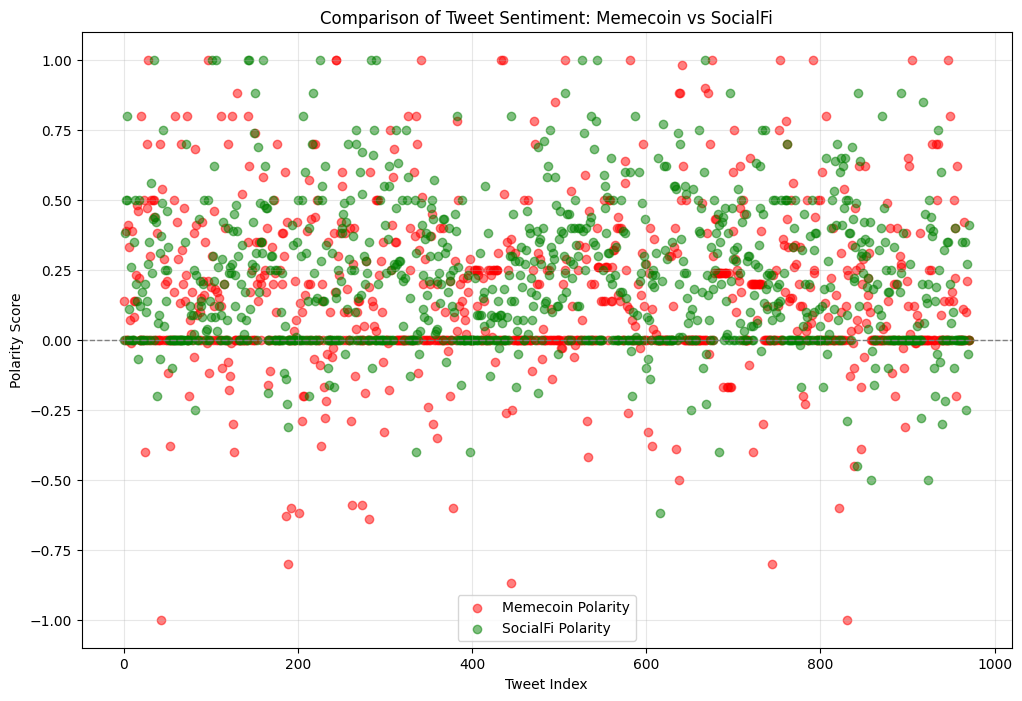

In [20]:
# Create a scatter chart for polarity scores in Control Group 

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Read the csv
df_memecoin = pd.read_excel('memecoin_sentiment_analysis_ConG.xlsx')
df_socialfi = pd.read_excel('socialfi_sentiment_analysis_ConG.xlsx')

# Read the polarity data
memecoin_polarity = df_memecoin['text_polarity'].values
socialfi_polarity = df_socialfi['text_polarity'].values

# Create indices
indices = np.arange(len(memecoin_polarity))

plt.figure(figsize=(12, 8))

# Create the scatter chart
plt.scatter(indices, memecoin_polarity, color='red', alpha=0.5, label="Memecoin Polarity")
plt.scatter(indices, socialfi_polarity, color='green', alpha=0.5, label="SocialFi Polarity")

# Add 0 line
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# Let's make the chart more readable
plt.xlabel("Tweet Index")
plt.ylabel("Polarity Score")
plt.title("Comparison of Tweet Sentiment: Memecoin vs SocialFi")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

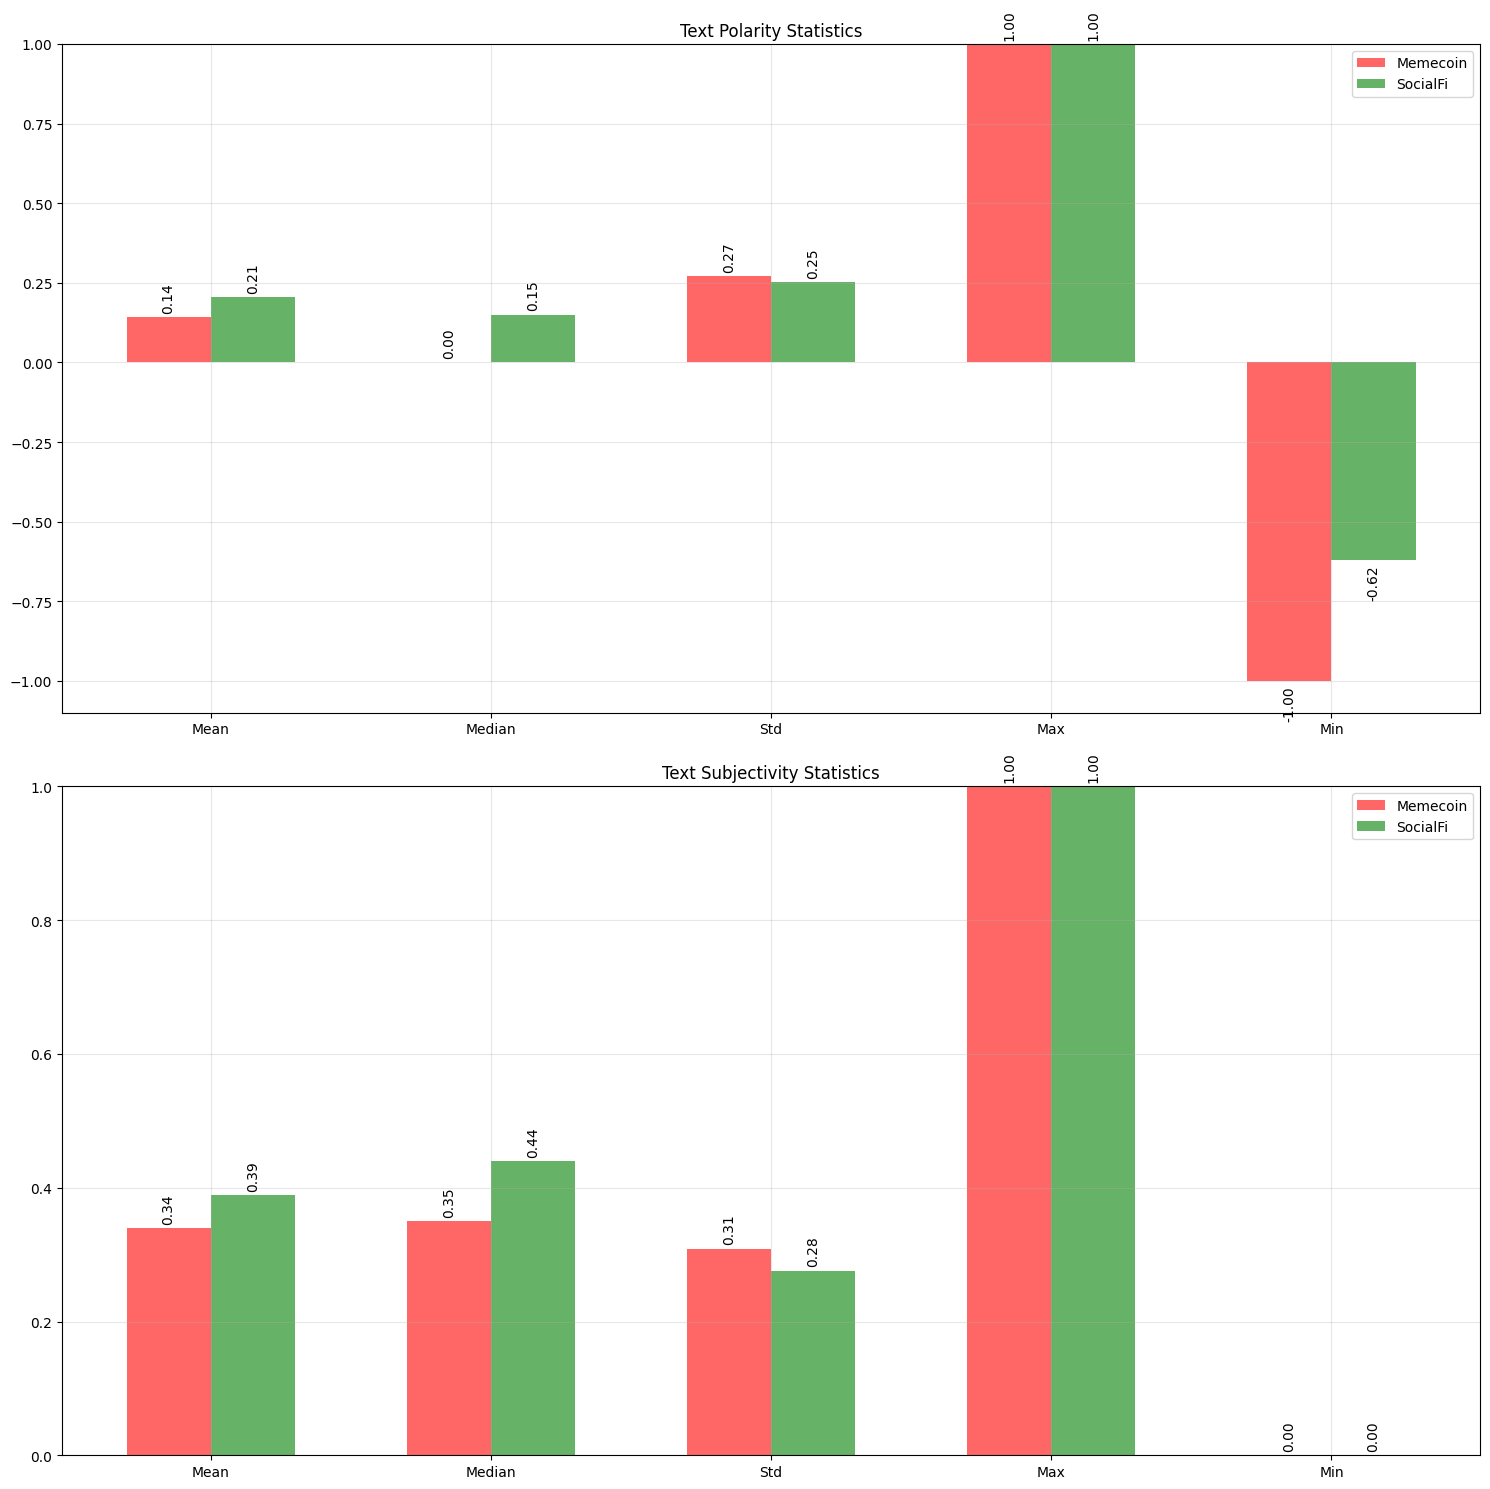


Combined Polarity Statistics:
Memecoin: {'Mean': np.float64(0.14124485596707817), 'Median': np.float64(0.0), 'Std': np.float64(0.27155158129172985), 'Max': np.float64(1.0), 'Min': np.float64(-1.0)}
SocialFi: {'Mean': np.float64(0.2054732510288066), 'Median': np.float64(0.15), 'Std': np.float64(0.25238284044463666), 'Max': np.float64(1.0), 'Min': np.float64(-0.62)}

Text Subjectivity Statistics:
Memecoin: {'Mean': np.float64(0.3394341563786008), 'Median': np.float64(0.35), 'Std': np.float64(0.3089665655140856), 'Max': np.float64(1.0), 'Min': np.float64(0.0)}
SocialFi: {'Mean': np.float64(0.38860082304526744), 'Median': np.float64(0.44), 'Std': np.float64(0.276159286860316), 'Max': np.float64(1.0), 'Min': np.float64(0.0)}


In [30]:
# Create bar charts to compare polarity and subjectivity scores in the Control Groups

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the data
df_memecoin = pd.read_excel('memecoin_sentiment_analysis_ConG.xlsx')
df_socialfi = pd.read_excel('socialfi_sentiment_analysis_ConG.xlsx')

# Calculate mean, median, standard deviation, 
def calculate_stats(df):
    polarity_stats = {
        'Mean': df['text_polarity'].mean(),
        'Median': df['text_polarity'].median(),
        'Std': df['text_polarity'].std(),
        'Max': df['text_polarity'].max(),
        'Min': df['text_polarity'].min()
    }
    
    subjectivity_stats = {
        'Mean': df['text_subjectivity'].mean(),
        'Median': df['text_subjectivity'].median(),
        'Std': df['text_subjectivity'].std(),
        'Max': df['text_subjectivity'].max(),
        'Min': df['text_subjectivity'].min()
    }
    
    return polarity_stats, subjectivity_stats

# Create the attributes for next steps
memecoin_polarity_stats, memecoin_subj_stats = calculate_stats(df_memecoin)
socialfi_polarity_stats, socialfi_subj_stats = calculate_stats(df_socialfi)

# Create the chart
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 15))

# Set metrics and arrange them on X axis
metrics = ['Mean', 'Median', 'Std', 'Max', 'Min']
x = np.arange(len(metrics))
width = 0.3

# Setup bar style of polarity
polarity_bars1 = ax1.bar(x - width/2, [memecoin_polarity_stats[m] for m in metrics], 
                        width, label='Memecoin', color='red', alpha=0.6)
polarity_bars2 = ax1.bar(x + width/2, [socialfi_polarity_stats[m] for m in metrics], 
                        width, label='SocialFi', color='green', alpha=0.6)

# Setup bar style of subjectivity
subj_bars1 = ax2.bar(x - width/2, [memecoin_subj_stats[m] for m in metrics], 
                     width, label='Memecoin', color='red', alpha=0.6)
subj_bars2 = ax2.bar(x + width/2, [socialfi_subj_stats[m] for m in metrics], 
                     width, label='SocialFi', color='green', alpha=0.6)

# Add data lable on the top of each bar
def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()

        # set minus data below the 0 line
        if height < 0:
            va = 'top'
            xytext = (0, -3)
        else:
            va = 'bottom'
            xytext = (0, 3)
            
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=xytext,
                    textcoords="offset points",
                    ha='center', va=va, rotation=90)

autolabel(polarity_bars1, ax1)
autolabel(polarity_bars2, ax1)
autolabel(subj_bars1, ax2)
autolabel(subj_bars2, ax2)

# Fulfill the style of whole chart
# Set -1=1 range for the Y axis for the Polarity chart
ax1.set_xticks(x)
ax1.set_xticklabels(metrics)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(min(min(memecoin_polarity_stats.values()), 
                min(socialfi_polarity_stats.values())) - 0.1, 1)
ax1.set_title('Text Polarity Statistics')

# Set 0-1 range for the Y axis for the Subjectivity chart
ax2.set_xticks(x)
ax2.set_xticklabels(metrics)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)  
ax2.set_title('Text Subjectivity Statistics')

ax1.set_title('Text Polarity Statistics')
ax2.set_title('Text Subjectivity Statistics')

plt.tight_layout()
plt.show()

# Print the data below the chart
print("\nCombined Polarity Statistics:")
print("Memecoin:", memecoin_polarity_stats)
print("SocialFi:", socialfi_polarity_stats)
print("\nText Subjectivity Statistics:")
print("Memecoin:", memecoin_subj_stats)
print("SocialFi:", socialfi_subj_stats)

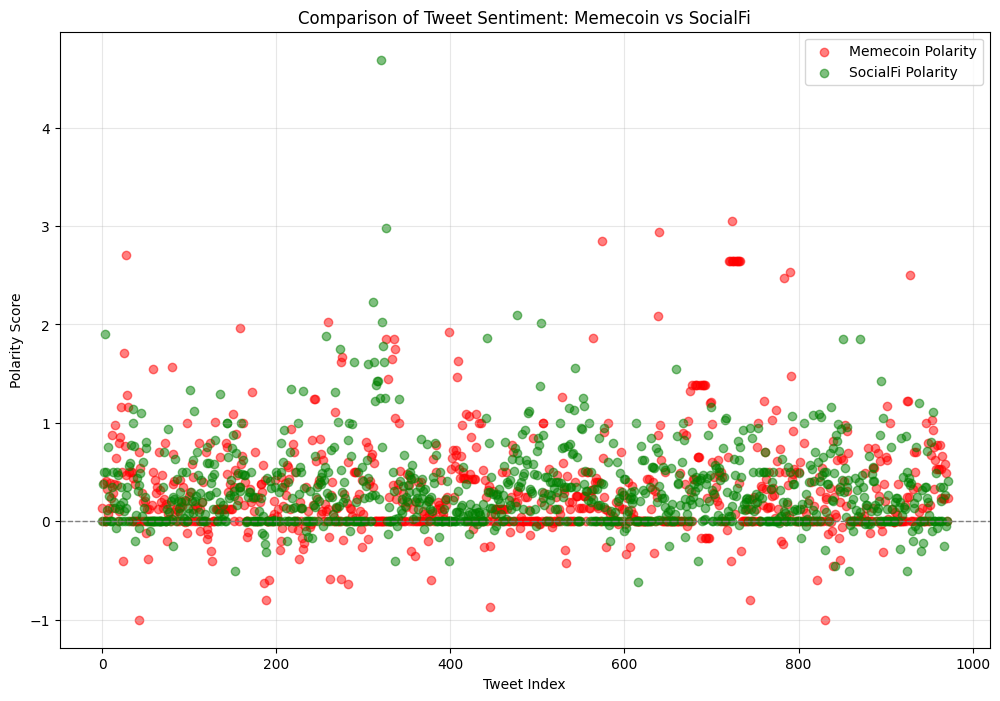

In [540]:
# Create a scatter chart for polarity scores in new group 

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Read the csv
df_memecoin = pd.read_excel('memecoin_sentiment_analysis_final.xlsx')
df_socialfi = pd.read_excel('socialfi_sentiment_analysis_final.xlsx')

# Read the polarity data
memecoin_polarity = df_memecoin['final_polarity'].values
socialfi_polarity = df_socialfi['final_polarity'].values

# Create indices
indices = np.arange(len(memecoin_polarity))

plt.figure(figsize=(12, 8))

# Create the scatter chart
plt.scatter(indices, memecoin_polarity, color='red', alpha=0.5, label="Memecoin Polarity")
plt.scatter(indices, socialfi_polarity, color='green', alpha=0.5, label="SocialFi Polarity")

# Add 0 line
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# Let's make the chart more readable
plt.xlabel("Tweet Index")
plt.ylabel("Polarity Score")
plt.title("Comparison of Tweet Sentiment: Memecoin vs SocialFi")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

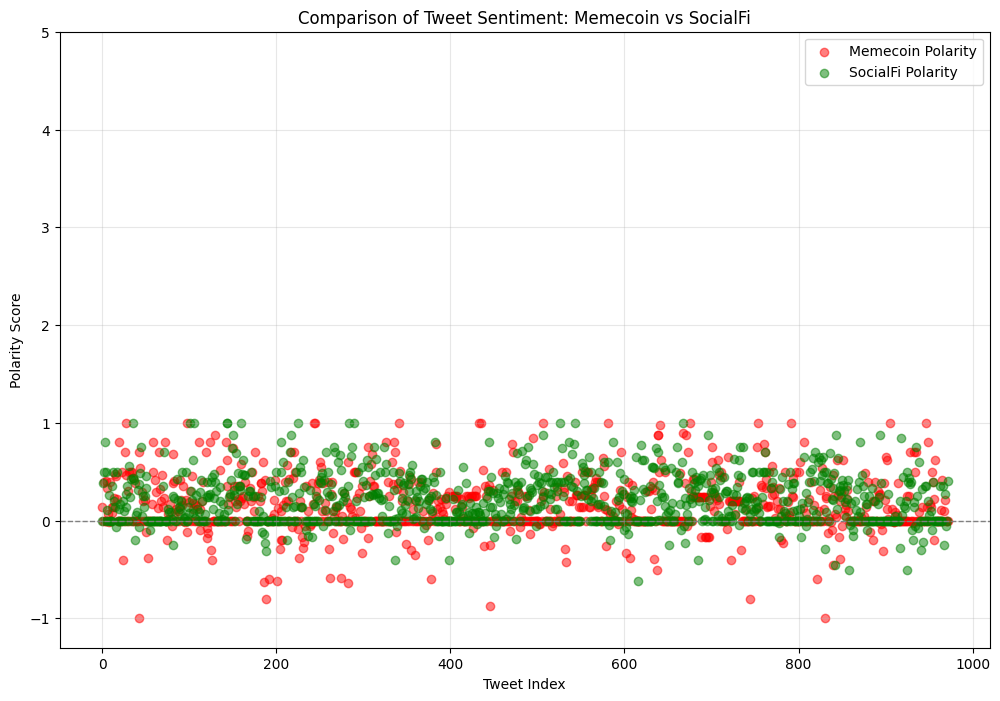

In [24]:
# I make the range of Y axis -1-4 in TextBlob model, in order to make clearer comparisons with the new model
# Create a scatter chart for polarity scores in Control Group 

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Read the csv
df_memecoin = pd.read_excel('memecoin_sentiment_analysis_ConG.xlsx')
df_socialfi = pd.read_excel('socialfi_sentiment_analysis_ConG.xlsx')

# Read the polarity data
memecoin_polarity = df_memecoin['text_polarity'].values
socialfi_polarity = df_socialfi['text_polarity'].values

# Create indices
indices = np.arange(len(memecoin_polarity))

plt.figure(figsize=(12, 8))

# Create the scatter chart
plt.scatter(indices, memecoin_polarity, color='red', alpha=0.5, label="Memecoin Polarity")
plt.scatter(indices, socialfi_polarity, color='green', alpha=0.5, label="SocialFi Polarity")

# Add 0 line
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# Set the y-axis limits
plt.ylim(-1.3, 5)

# Let's make the chart more readable
plt.xlabel("Tweet Index")
plt.ylabel("Polarity Score")
plt.title("Comparison of Tweet Sentiment: Memecoin vs SocialFi")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

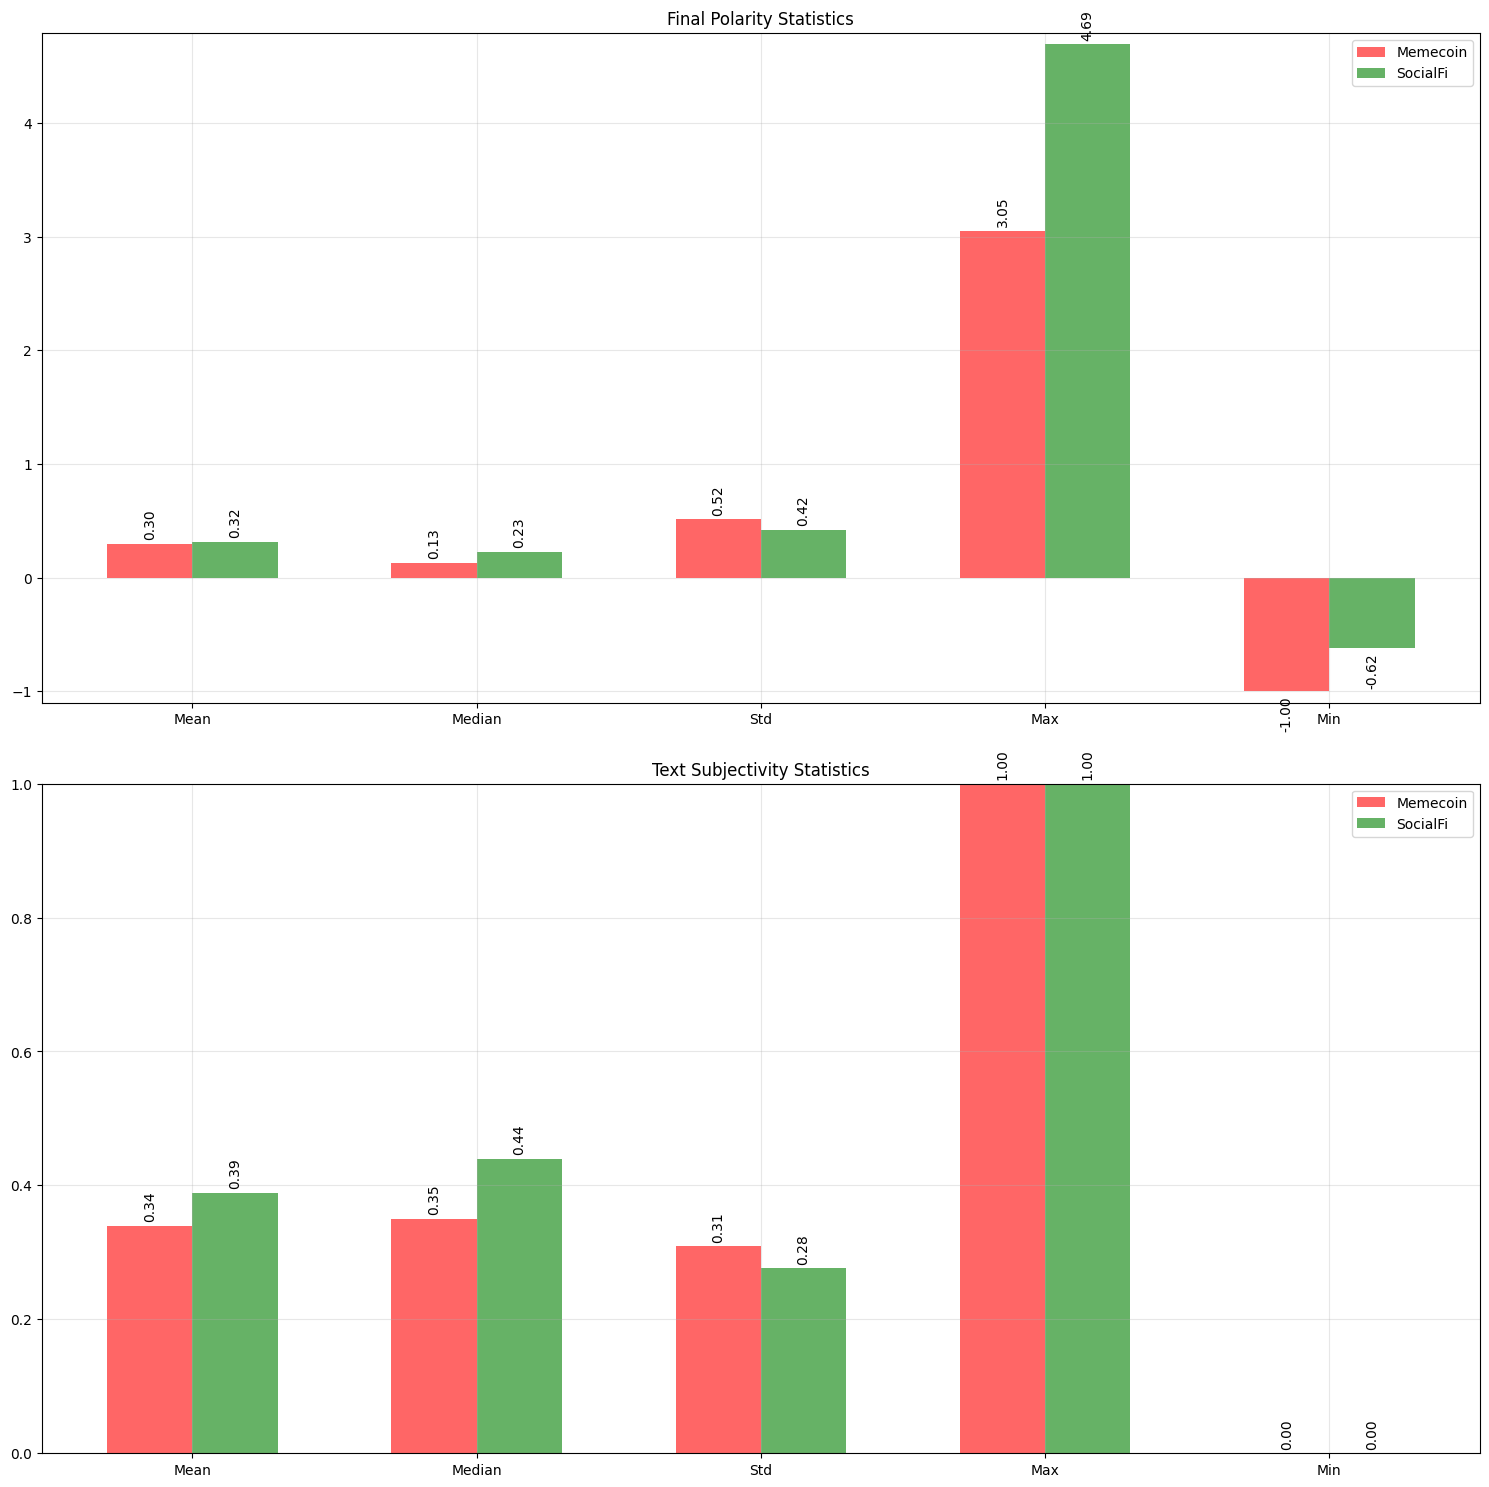


Component Polarity Statistics:
Memecoin: {'Mean': np.float64(0.2986831275720164), 'Median': np.float64(0.13), 'Std': np.float64(0.5154961358931754), 'Max': np.float64(3.05), 'Min': np.float64(-1.0)}
SocialFi: {'Mean': np.float64(0.31767489711934155), 'Median': np.float64(0.23), 'Std': np.float64(0.42122173497816096), 'Max': np.float64(4.69), 'Min': np.float64(-0.62)}

Text Subjectivity Statistics:
Memecoin: {'Mean': np.float64(0.3394341563786008), 'Median': np.float64(0.35), 'Std': np.float64(0.3089665655140856), 'Max': np.float64(1.0), 'Min': np.float64(0.0)}
SocialFi: {'Mean': np.float64(0.38860082304526744), 'Median': np.float64(0.44), 'Std': np.float64(0.276159286860316), 'Max': np.float64(1.0), 'Min': np.float64(0.0)}


In [26]:
# This is the Bar Chart of new method

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the data
df_memecoin = pd.read_excel('memecoin_sentiment_analysis_final.xlsx')
df_socialfi = pd.read_excel('socialfi_sentiment_analysis_final.xlsx')

# Calculate mean, median, standard deviation, 
def calculate_stats(df):
    polarity_stats = {
        'Mean': df['final_polarity'].mean(),
        'Median': df['final_polarity'].median(),
        'Std': df['final_polarity'].std(),
        'Max': df['final_polarity'].max(),
        'Min': df['final_polarity'].min()
    }
    
    subjectivity_stats = {
        'Mean': df['text_subjectivity'].mean(),
        'Median': df['text_subjectivity'].median(),
        'Std': df['text_subjectivity'].std(),
        'Max': df['text_subjectivity'].max(),
        'Min': df['text_subjectivity'].min()
    }
    
    return polarity_stats, subjectivity_stats

# Create the attributes for next steps
memecoin_polarity_stats, memecoin_subj_stats = calculate_stats(df_memecoin)
socialfi_polarity_stats, socialfi_subj_stats = calculate_stats(df_socialfi)

# Create the chart
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 15))

# Set metrics and arrange them on X axis
metrics = ['Mean', 'Median', 'Std', 'Max', 'Min']
x = np.arange(len(metrics))
width = 0.3

# Setup bar style of polarity
polarity_bars1 = ax1.bar(x - width/2, [memecoin_polarity_stats[m] for m in metrics], 
                        width, label='Memecoin', color='red', alpha=0.6)
polarity_bars2 = ax1.bar(x + width/2, [socialfi_polarity_stats[m] for m in metrics], 
                        width, label='SocialFi', color='green', alpha=0.6)

# Setup bar style of subjectivity
subj_bars1 = ax2.bar(x - width/2, [memecoin_subj_stats[m] for m in metrics], 
                     width, label='Memecoin', color='red', alpha=0.6)
subj_bars2 = ax2.bar(x + width/2, [socialfi_subj_stats[m] for m in metrics], 
                     width, label='SocialFi', color='green', alpha=0.6)

# Add data lable on the top of each bar
def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()

        # set minus data below the 0 line
        if height < 0:
            va = 'top'
            xytext = (0, -3)
        else:
            va = 'bottom'
            xytext = (0, 3)
            
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=xytext,
                    textcoords="offset points",
                    ha='center', va=va, rotation=90)

autolabel(polarity_bars1, ax1)
autolabel(polarity_bars2, ax1)
autolabel(subj_bars1, ax2)
autolabel(subj_bars2, ax2)

# Fulfill the style of whole chart
# Set range for the Y axis for the Polarity chart
ax1.set_xticks(x)
ax1.set_xticklabels(metrics)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(min(min(memecoin_polarity_stats.values()), 
                min(socialfi_polarity_stats.values())) - 0.1, 
             max(max(memecoin_polarity_stats.values()),
                max(socialfi_polarity_stats.values())) + 0.1)
ax1.set_title('Final Polarity Statistics')

# Set 0-1 range for the Y axis for the Subjectivity chart
ax2.set_xticks(x)
ax2.set_xticklabels(metrics)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)  
ax2.set_title('Text Subjectivity Statistics')

ax1.set_title('Final Polarity Statistics')
ax2.set_title('Text Subjectivity Statistics')

plt.tight_layout()
plt.show()

# Print the data below the chart
print("\nComponent Polarity Statistics:")
print("Memecoin:", memecoin_polarity_stats)
print("SocialFi:", socialfi_polarity_stats)
print("\nText Subjectivity Statistics:")
print("Memecoin:", memecoin_subj_stats)
print("SocialFi:", socialfi_subj_stats)